# Industrial Defect Segmentation on MVTec AD & VisA (YOLO11-seg → TensorRT C++)

Instance segmentation of surface defects: each defect gets a pixel mask plus the category of the part it sits on
(15 MVTec categories, e.g. `bottle`, `cable`, `leather`, `screw`). The project covers:

1. **Dataset engineering.** MVTec ground-truth masks become YOLO polygons, and the background-heavy VisA split is rebalanced.
2. **Model experiments.** YOLO11l-seg at 640 px, genetic hyperparameter evolution, and a YOLO11x-seg run at 1024 px.
3. **Evaluation beyond mAP.** Per-category AP, plus the false-alarm rate on **defect-free parts the model never saw**.
4. **Deployment.** A TensorRT engine served from a C++ application with a CUDA stream and pinned memory, which decodes boxes and masks itself.

| Result | Value |
|---|---|
| MVTec mask mAP50 / mAP50-95 (YOLO11l-seg, 640 px, `best.pt`) | 0.819 / 0.482 |
| MVTec mask mAP50 / mAP50-95 (YOLO11x-seg, 1024 px, evolved hyper-params) | 0.823 / 0.473 |
| VisA mask mAP50: unbalanced → balanced training set | 0.250 → **0.410** |
| C++ TensorRT app on 15 held-out defects (one per category) | 11 located (mask IoU ≥ 0.5), 1 partly covered, 2 over-segmented, 1 missed |
| TensorRT engine latency, YOLO11x-seg at 1024×1024 (`trtexec`) | mean 6.7 ms · p99 7.2 ms |

**How to read this notebook.** Result cells run on artefacts saved from the original runs in `results/`. Training, tuning and export cells are
the runnable pipeline. They need the MVTec AD / VisA data and a CUDA GPU (runs were done on an RTX 5080) and were not re-executed here.

## 0 · Setup

In [ ]:
import io, json, os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import Markdown, display, Image as IPyImage

RESULTS = Path("results")          # everything saved from the original runs lives here
FIG = RESULTS / "figures"

def show(path, width=1100, caption=None):
    """Display a saved result image, downscaled so the notebook stays small."""
    im = Image.open(path).convert("RGB")
    if im.width > width:
        im = im.resize((width, round(im.height * width / im.width)), Image.LANCZOS)
    buf = io.BytesIO(); im.save(buf, format="JPEG", quality=85)
    if caption:
        display(Markdown(f"*{caption}*"))
    display(IPyImage(data=buf.getvalue(), format="jpeg"))

def show_pair(left, right, titles=("", ""), width=1400, gap=12):
    """Two result images side by side (e.g. ground truth vs prediction), embedded as one JPEG."""
    ims = [Image.open(p).convert("RGB") for p in (left, right)]
    h = min(im.height for im in ims)
    ims = [im.resize((round(im.width * h / im.height), h), Image.LANCZOS) for im in ims]
    canvas = Image.new("RGB", (ims[0].width + gap + ims[1].width, h), (252, 252, 251))
    canvas.paste(ims[0], (0, 0)); canvas.paste(ims[1], (ims[0].width + gap, 0))
    if canvas.width > width:
        canvas = canvas.resize((width, round(canvas.height * width / canvas.width)), Image.LANCZOS)
    buf = io.BytesIO(); canvas.save(buf, format="JPEG", quality=85)
    if any(titles):
        display(Markdown(f"*Left: {titles[0]} · Right: {titles[1]}*"))
    display(IPyImage(data=buf.getvalue(), format="jpeg"))

# Chart style: light surface, hairline grid, text in ink colours, fixed categorical order.
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
mpl.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "savefig.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7", "axes.grid": True, "axes.axisbelow": True,
    "grid.color": "#e1e0d9", "grid.linewidth": 0.8, "grid.linestyle": "-",
    "axes.spines.top": False, "axes.spines.right": False,
    "text.color": INK, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.titlesize": 12, "axes.titleweight": "semibold", "axes.titlelocation": "left",
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelcolor": INK2, "ytick.labelcolor": INK2,
    "lines.linewidth": 2, "lines.solid_capstyle": "round", "legend.frameon": False,
    "axes.prop_cycle": mpl.cycler(color=SERIES), "figure.dpi": 110, "savefig.dpi": 160,
})

MVTEC_ROOT = Path(os.environ.get("MVTEC_ROOT", "data/mvtec_ad"))   # <category>/{train,test,ground_truth}
MVTEC_YOLO = Path("data/mvtec_yolo")
VISA_YOLO  = Path("data/visa_yolo")
RUNS = RESULTS / "metrics/runs"

## 1 · Data: MVTec AD masks → YOLO polygons

MVTec AD provides pixel-accurate masks only for the defective **test** images. `src/format_mvtec_to_yolo.py` walks every category and
defect type, splits each defect type 80/20, thresholds each mask, extracts external contours and writes them as normalised YOLO polygons.
The class id is the **part category**, so the model localises the defect and names the part.
Result: **977 train / 281 val images with 1,461 / 427 defect polygons**. Defect-free (`good`) images are not used for training.

In [ ]:
import cv2, random, shutil

def format_mvtec_to_yolo(source_dir: Path, dest_dir: Path, split_ratio=0.8):
    classes = [d.name for d in sorted(source_dir.iterdir()) if (d / "test").is_dir()]
    for sub in ("images/train", "images/val", "labels/train", "labels/val"):
        (dest_dir / sub).mkdir(parents=True, exist_ok=True)
    yaml = "path: .\ntrain: images/train\nval: images/val\n\nnames:\n"
    for class_id, obj in enumerate(classes):
        yaml += f"  {class_id}: {obj}\n"
        for defect in [d.name for d in (source_dir / obj / "test").iterdir() if d.name != "good"]:
            images = sorted(p.name for p in (source_dir / obj / "test" / defect).iterdir())
            random.shuffle(images)
            train_set = set(images[:int(len(images) * split_ratio)])
            for name in images:
                subset = "train" if name in train_set else "val"
                new_name = f"{obj}_{defect}_{name}"
                shutil.copy(source_dir / obj / "test" / defect / name, dest_dir / "images" / subset / new_name)
                mask_path = source_dir / obj / "ground_truth" / defect / f"{Path(name).stem}_mask.png"
                if not mask_path.exists():
                    continue
                mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
                h, w = mask.shape
                _, binary = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
                contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
                with open(dest_dir / "labels" / subset / new_name.replace(".png", ".txt"), "w") as f:
                    for c in contours:
                        if len(c) > 2:
                            f.write(f"{class_id} " + " ".join(f"{p[0][0] / w:.6f} {p[0][1] / h:.6f}" for p in c) + "\n")
    (dest_dir / "mvtec.yaml").write_text(yaml)

format_mvtec_to_yolo(MVTEC_ROOT, MVTEC_YOLO)

## 2 · Baseline: YOLO11l-seg at 640 px

COCO-pretrained YOLO11l-seg, 100 epochs, 640 px, batch 16, default augmentation (`src/train_and_export.py`).

In [ ]:
from ultralytics import YOLO

model = YOLO("yolo11l-seg.pt")
model.train(data=str(MVTEC_YOLO / "mvtec.yaml"), epochs=100, imgsz=640, batch=16, device=0,
            project="industrial_pipeline", name="defect_seg")

In [1]:
def final(name):
    df = pd.read_csv(RUNS / f"{name}_results.csv"); df.columns = [c.strip() for c in df.columns]
    last = df.iloc[-1]
    return {"epochs": int(last["epoch"]),
            "box mAP50": last["metrics/mAP50(B)"], "box mAP50-95": last["metrics/mAP50-95(B)"],
            "mask mAP50": last["metrics/mAP50(M)"], "mask mAP50-95": last["metrics/mAP50-95(M)"],
            "best mask mAP50": df["metrics/mAP50(M)"].max(), "hours": last["time"] / 3600}

RUN_LABELS = {
    "mvtec_yolo11l-seg_640":        "MVTec · YOLO11l-seg · 640",
    "mvtec_yolo11x-seg_1024_tuned": "MVTec · YOLO11x-seg · 1024 · evolved",
    "visa_yolo11n-seg_unbalanced":  "VisA · YOLO11n-seg · unbalanced",
    "visa_yolo11l-seg_unbalanced":  "VisA · YOLO11l-seg · unbalanced",
    "visa_yolo11l-seg_balanced":    "VisA · YOLO11l-seg · balanced",
}
runs = pd.DataFrame({label: final(name) for name, label in RUN_LABELS.items()}).T
runs.round(3)

,epochs,box mAP50,box mAP50-95,mask mAP50,mask mAP50-95,best mask mAP50,hours
MVTec · YOLO11l-seg · 640,100.0,0.835,0.564,0.825,0.485,0.832,0.419
MVTec · YOLO11x-seg · 1024 · evolved,150.0,0.825,0.530,0.808,0.467,0.823,2.493
VisA · YOLO11n-seg · unbalanced,100.0,0.287,0.146,0.253,0.124,0.260,1.084
VisA · YOLO11l-seg · unbalanced,100.0,0.281,0.136,0.250,0.118,0.250,3.699
VisA · YOLO11l-seg · balanced,100.0,0.457,0.289,0.410,0.214,0.414,0.642


*YOLO11l-seg @ 640 on MVTec: losses and box/mask metrics over 100 epochs.*

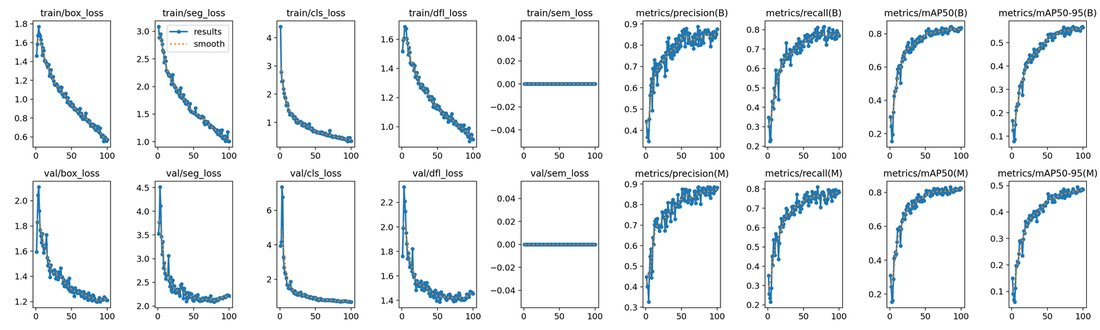

In [2]:
show(FIG / "l640_training_curves.png", caption="YOLO11l-seg @ 640 on MVTec: losses and box/mask metrics over 100 epochs.")

## 3 · VisA: fixing class imbalance

The VisA training split is dominated by defect-free ("background") images. Two YOLO11l-seg runs used **identical settings** (their
`args.yaml` files differ only in run name), including stronger geometric augmentation (rotation ±15°, translate 0.2, vertical flip 0.5,
mixup 0.2). The only change between them is `src/balance_visa.py`, which randomly keeps background images equal to 10% of the anomaly count.
(The VisA → YOLO conversion used VisA's `1cls` split CSV; that converter was not preserved.)

In [ ]:
import os, random

def balance_visa(train_images_dir: Path, keep_ratio=0.10, seed=0):
    images = os.listdir(train_images_dir)
    normal = [i for i in images if "_normal_" in i]
    anomaly = [i for i in images if "_anomaly_" in i]
    random.seed(seed); random.shuffle(normal)
    for name in normal[int(len(anomaly) * keep_ratio):]:
        os.remove(train_images_dir / name)
    print(f"kept {len(anomaly)} defect images and {int(len(anomaly) * keep_ratio)} background images")

AUG = dict(degrees=15.0, translate=0.2, flipud=0.5, fliplr=0.5, mixup=0.2, hsv_v=0.5)   # as recorded in args.yaml
YOLO("yolo11l-seg.pt").train(data=str(VISA_YOLO / "visa.yaml"), epochs=100, imgsz=640, batch=16, device=0,
                             project="industrial_pipeline", name="visa_robust_seg", **AUG)
balance_visa(VISA_YOLO / "images/train")
YOLO("yolo11l-seg.pt").train(data=str(VISA_YOLO / "visa.yaml"), epochs=100, imgsz=640, batch=16, device=0,
                             project="industrial_pipeline", name="visa_balanced_robust_seg", **AUG)

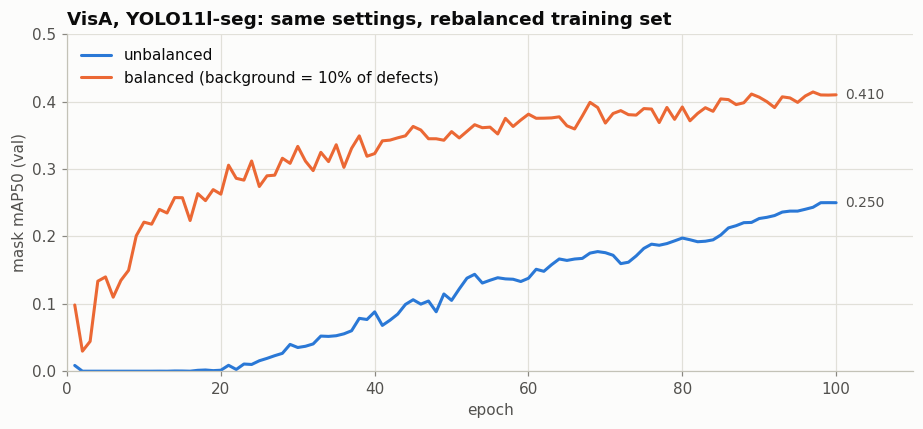

In [3]:
fig, ax = plt.subplots(figsize=(8.5, 4))
for (name, label), color in zip([("visa_yolo11l-seg_unbalanced", "unbalanced"), ("visa_yolo11l-seg_balanced", "balanced (background = 10% of defects)")], SERIES):
    df = pd.read_csv(RUNS / f"{name}_results.csv"); df.columns = [c.strip() for c in df.columns]
    ax.plot(df["epoch"], df["metrics/mAP50(M)"], color=color, label=label)
    ax.annotate(f'{df["metrics/mAP50(M)"].iloc[-1]:.3f}', (df["epoch"].iloc[-1], df["metrics/mAP50(M)"].iloc[-1]),
                xytext=(6, 0), textcoords="offset points", va="center", fontsize=9, color=INK2)
ax.set_xlim(0, 110); ax.set_ylim(0, 0.5); ax.set_xlabel("epoch"); ax.set_ylabel("mask mAP50 (val)")
ax.set_title("VisA, YOLO11l-seg: same settings, rebalanced training set")
ax.legend(loc="upper left")
plt.tight_layout(); fig.savefig(FIG / "visa_balancing_effect.png"); plt.show()

Rebalancing lifts VisA mask mAP50 from **0.250 to 0.410** (box mAP50 0.281 → 0.457) with no change to the model or the recipe.
VisA stays far harder than MVTec: most of its defect boxes cover less than 5% of the image width, across 12 product types that include
four PCB variants.

## 4 · Hyperparameter evolution

Ultralytics' genetic tuner mutates the optimiser, loss-weight and augmentation settings, trains for 30 epochs per iteration
(YOLO11x-seg, 1024 px) and keeps the fittest set.

In [ ]:
YOLO("yolo11x-seg.pt").tune(data=str(MVTEC_YOLO / "mvtec.yaml"), epochs=30, iterations=20, imgsz=1024, batch=12,
                            device=0, plots=False, save=False, val=True)    # -> runs/segment/tune-2

In [4]:
tune = pd.DataFrame([json.loads(l) for l in open(RESULTS / "metrics/tuning/tune_results.ndjson")])
tune["mask mAP50"] = [d.get("mvtec", {}).get("metrics/mAP50(M)") for d in tune["datasets"]]
tune["status"] = np.where(tune["fitness"] > 0, "completed", "failed (fitness 0)")
print(tune["status"].value_counts().to_string())
best = pd.Series(tune.loc[tune["fitness"].idxmax(), "hyperparameters"])
default = pd.Series(tune.loc[0, "hyperparameters"])            # iteration 1 = Ultralytics defaults
changed = pd.DataFrame({"default": default, "evolved": best})
rel = (changed["evolved"] - changed["default"]).abs() / changed["default"].abs().replace(0, np.nan)
changed[(rel > 0.05) | ((changed["default"] == 0) & (changed["evolved"].abs() > 0.005))].round(4)

status
failed (fitness 0)    18
completed              2


,default,evolved
weight_decay,0.0005,0.0010
warmup_epochs,3.0000,3.8343
warmup_momentum,0.8000,0.9020
cls_pw,0.0000,0.0052
hsv_s,0.7000,0.9000
copy_paste,0.0000,0.0101


Only **2 of 20 iterations completed**. The other 18 ended with fitness 0, and an earlier 30-iteration attempt ended after 3 iterations.
The "evolved" set therefore comes from a single mutation of the defaults: slightly lower momentum, higher weight decay, stronger
saturation jitter and a longer warm-up. That explains why it changed little in the final run below. A real search needs a smaller
proxy (e.g. YOLO11s at 640 px, 10 epochs) so that each iteration fits in memory and time.

## 5 · Scaling up: YOLO11x-seg at 1024 px with the evolved settings

`src/train_final_1024.py`: 150 epochs, 1024 px, batch 8, `cfg=best_hyperparameters.yaml` (about 2.5 h on the RTX 5080).

In [ ]:
YOLO("yolo11x-seg.pt").train(data=str(MVTEC_YOLO / "mvtec.yaml"), cfg="runs/segment/tune-2/best_hyperparameters.yaml",
                             epochs=150, imgsz=1024, batch=8, device=0, workers=8,
                             project="industrial_pipeline", name="mvtec_ultimate_seg")

Section 7 shows this model's output case by case, run through the C++ TensorRT application on held-out images.

## 6 · Evaluation beyond a single mAP

`src/eval_per_category.py` re-validates both MVTec models' `best.pt` on the validation split with per-category AP. It also runs them on the **467 defect-free
MVTec test images** (`<category>/test/good`). Those images were never used, because training only saw defective parts. Any predicted
instance on such an image is a false alarm, which on a production line means a good part rejected.

In [5]:
ap = pd.read_csv(RESULTS / "metrics/extra_eval/per_category_ap.csv")
overall = ap[ap.category == "ALL"].set_index("model").drop(columns="category")
overall.round(3)

,box_AP50,box_AP50_95,mask_AP50,mask_AP50_95
model,,,,
yolo11l-seg_640,0.830,0.567,0.819,0.482
yolo11x-seg_1024_tuned,0.831,0.535,0.823,0.473


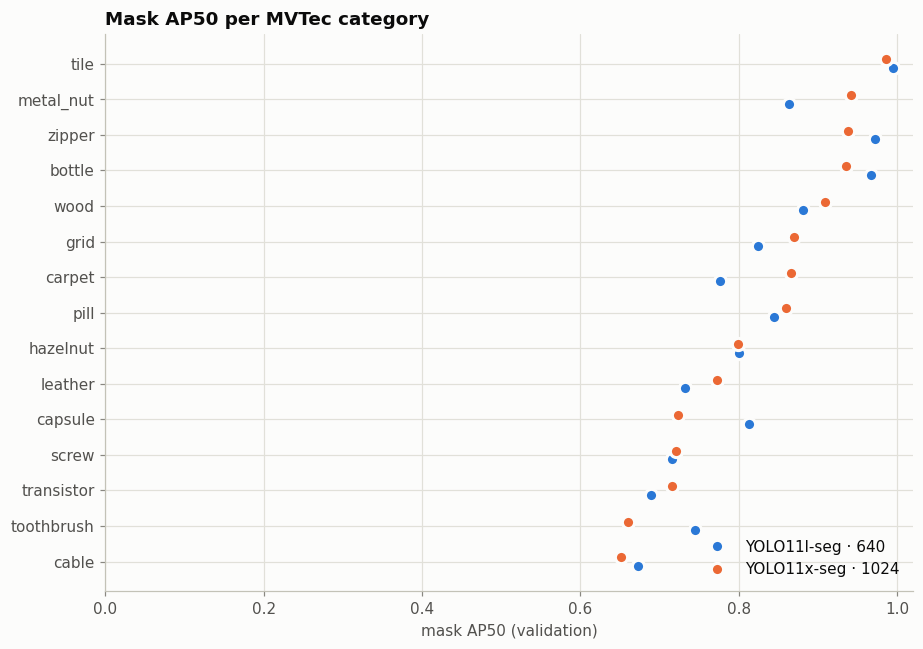

category,cable,toothbrush,transistor,screw,capsule,leather,hazelnut,pill,carpet,grid,wood,bottle,zipper,metal_nut,tile
model,,,,,,,,,,,,,,,
yolo11l-seg_640,0.673,0.745,0.689,0.716,0.813,0.732,0.801,0.844,0.776,0.825,0.881,0.967,0.972,0.864,0.995
yolo11x-seg_1024_tuned,0.652,0.660,0.716,0.720,0.723,0.773,0.799,0.859,0.865,0.870,0.909,0.935,0.938,0.942,0.986


In [6]:
per_cat = ap[ap.category != "ALL"].pivot(index="category", columns="model", values="mask_AP50")
per_cat = per_cat.sort_values("yolo11x-seg_1024_tuned")
fig, ax = plt.subplots(figsize=(8.5, 6))
y = np.arange(len(per_cat))
for (col, label), color, dy in zip([("yolo11l-seg_640", "YOLO11l-seg · 640"), ("yolo11x-seg_1024_tuned", "YOLO11x-seg · 1024")], SERIES, (-0.12, 0.12)):
    ax.plot(per_cat[col], y + dy, "o", ms=8, color=color, mec="#fcfcfb", mew=2, ls="none", label=label)
ax.set_yticks(y, per_cat.index); ax.set_xlim(0, 1.02); ax.set_xlabel("mask AP50 (validation)")
ax.set_title("Mask AP50 per MVTec category")
ax.legend(loc="lower right")
plt.tight_layout(); fig.savefig(FIG / "per_category_mask_ap50.png"); plt.show()
per_cat.round(3).T

In [7]:
fa = pd.read_csv(RESULTS / "metrics/extra_eval/false_alarms_on_good_parts.csv")
fa_summary = pd.read_csv(RESULTS / "metrics/extra_eval/false_alarms_summary.csv", index_col=0)
display(fa_summary.round(3))
fa.pivot(index="category", columns="model", values="false_alarm_rate_conf025").round(2).T

,good_images,false_alarm_rate_conf025,false_alarm_rate_conf050
model,,,
yolo11l-seg_640,467.0,0.045,0.021
yolo11x-seg_1024_tuned,467.0,0.088,0.024


category,bottle,cable,capsule,carpet,grid,hazelnut,leather,metal_nut,pill,screw,tile,toothbrush,transistor,wood,zipper
model,,,,,,,,,,,,,,,
yolo11l-seg_640,0.0,0.12,0.04,0.18,0.00,0.10,0.00,0.0,0.04,0.00,0.06,0.0,0.00,0.05,0.00
yolo11x-seg_1024_tuned,0.1,0.12,0.17,0.18,0.05,0.05,0.03,0.0,0.00,0.02,0.00,0.0,0.28,0.00,0.03


**Reading the numbers.**

* **Model size did not help.** Both models reach the same mask mAP50 (0.819 vs 0.823), so 4× the pixels and a 2.2× larger network
  (62.1M vs 27.7M parameters) bought nothing on this split.
* **Objects are harder than textures.** The weakest categories are objects with small or subtle defects: cable, toothbrush, transistor, screw
  and capsule (mask AP50 0.65–0.81). Most textures score higher (tile 0.99, wood 0.88–0.91), with leather the exception. Each category has
  only 6–31 validation images, so single-category differences are noisy.
* **False alarms.** At confidence 0.25, the 640 px model flags 4.5% of defect-free parts and the 1024 px model 8.8% (28% of good transistors,
  17% of good capsules). At confidence 0.5 both fall to about 2%. The model never saw a good part in training, so the threshold alone trades
  missed defects against rejected good parts.
* The validation split was also used to pick `best.pt`, so these numbers are slightly optimistic. MVTec has no separate labelled test split
  for this setup.

## 7 · Deployment: TensorRT engine + C++ inference

The 1024 px model is exported to ONNX (`images` 1×3×1024×1024 → `output0` 1×51×21504, `output1` 1×32×256×256) and built into a
TensorRT engine (`best_1024.engine`). `cpp/trt_seg_inference/main.cpp` then does everything outside the network itself:

* deserialises the engine and allocates **pinned host buffers** (`cudaHostAlloc`) and device buffers on a **CUDA stream**;
* pre-processes with OpenCV (resize, BGR→RGB, /255, HWC→CHW directly into the pinned buffer);
* runs `enqueueV3` with **async H2D / D2H copies**, then decodes the 21,504 proposals (4 box + 15 class scores + 32 mask coefficients);
* applies confidence 0.5 + `cv::dnn::NMSBoxes`, multiplies the mask coefficients with the 32×256×256 prototypes, applies a sigmoid, upsamples, and crops to the box;
* draws boxes and masks and writes `final_output_1024.jpg`.

**Engine rebuild.** A TensorRT engine only loads with the TensorRT version that built it. After the system moved to TensorRT 11.3, the
June engine no longer loaded, and the app crashed instead of saying so. The engine was rebuilt from the same ONNX with `trtexec`, and `main.cpp`
now checks for a failed load. `trtexec` measures the rebuilt engine at **6.7 ms mean / 7.2 ms p99** per 1024×1024 image (FP32 graph,
RTX 5080), about 150 images/s. This is GPU time only; the C++ app's own pre- and post-processing are not included.

In [ ]:
YOLO("runs/segment/industrial_pipeline/mvtec_ultimate_seg-2/weights/best.pt").export(format="onnx", imgsz=1024)
# trtexec --onnx=best.onnx --saveEngine=best_1024.engine        (FP32 graph; TensorRT 11 builds strongly typed)
# cmake -S cpp/trt_seg_inference -B build && cmake --build build

### Held-out demo, one image per case

The demo covers one random **validation** image per category (seed 0, never trained on) plus two random defect-free parts.
`cpp/trt_seg_inference/run_demo.sh` runs the unchanged C++ binary once per image. `src/render_cpp_demo.py` then puts each case's ground-truth outline
(yellow, left) next to the C++ output (right). The app paints its masks with a red tint, so the renderer recovers the C++ mask from the
output image and scores it against the ground truth.

In [ ]:
# bash cpp/trt_seg_inference/run_demo.sh build/inference best_1024.engine demo_raw results/cpp_demo/cases.csv <MVTec root>
# python src/render_cpp_demo.py --mvtec <MVTec root> --cases results/cpp_demo/cases.csv --raw demo_raw --out results/cpp_demo

In [8]:
demo = pd.read_csv(RESULTS / "cpp_demo/cpp_demo_summary.csv")
display(demo[["case", "predicted_classes", "max_confidence", "mask_iou", "verdict"]].round(2))
print(demo["verdict"].value_counts().to_string())

,case,predicted_classes,max_confidence,mask_iou,verdict
0,bottle_broken_small_017,bottle,0.93,0.67,located
1,cable_bent_wire_006,cable,0.91,0.79,located
2,capsule_squeeze_012,capsule,0.72,0.29,over-segmented
3,carpet_metal_contamination_009,carpet,0.93,0.84,located
4,grid_metal_contamination_004,grid,0.89,0.78,located
5,hazelnut_cut_008,hazelnut,0.82,0.77,located
6,leather_fold_002,leather,0.64,0.50,partly covered
7,metal_nut_bent_023,metal_nut,0.94,0.60,located
8,pill_scratch_013,pill,0.99,0.86,located
9,screw_thread_top_017,NaN,NaN,0.00,missed


verdict
located                  11
over-segmented            2
partly covered            1
missed                    1
false alarm               1
correct: no detection     1


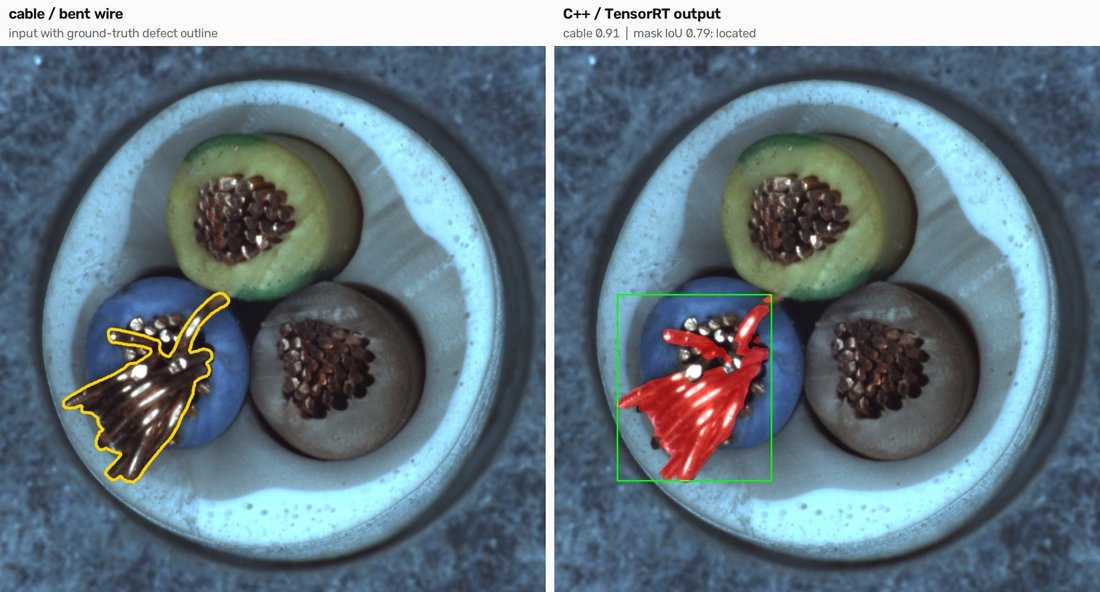

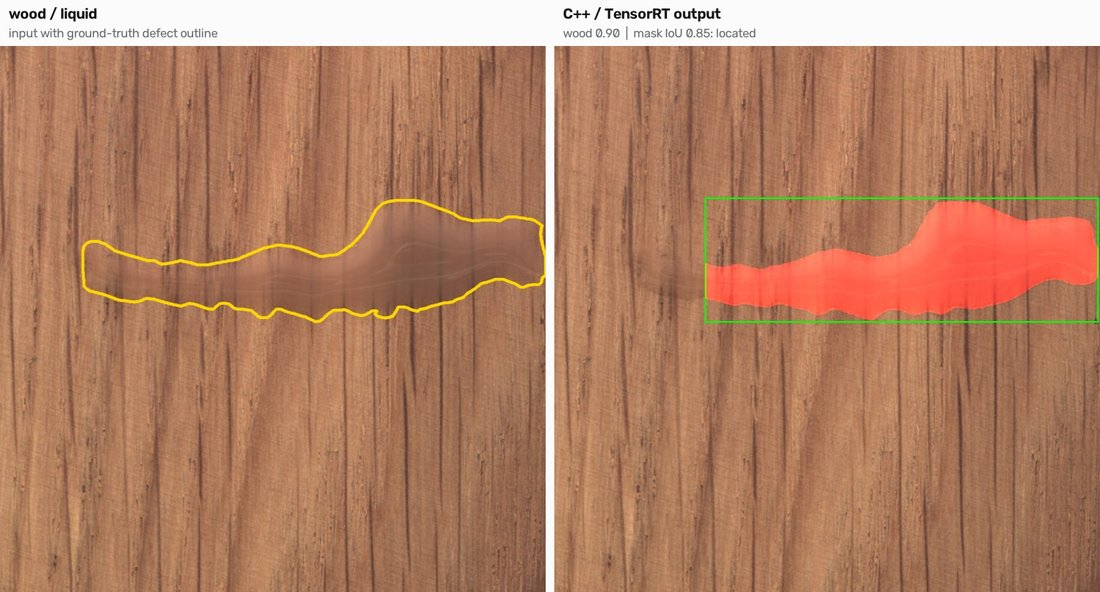

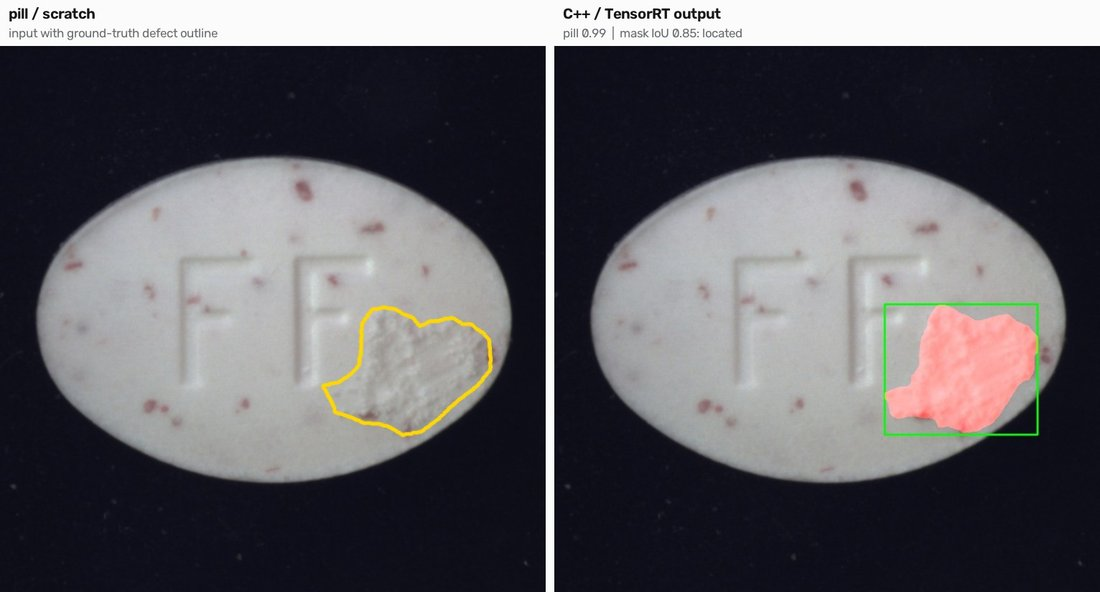

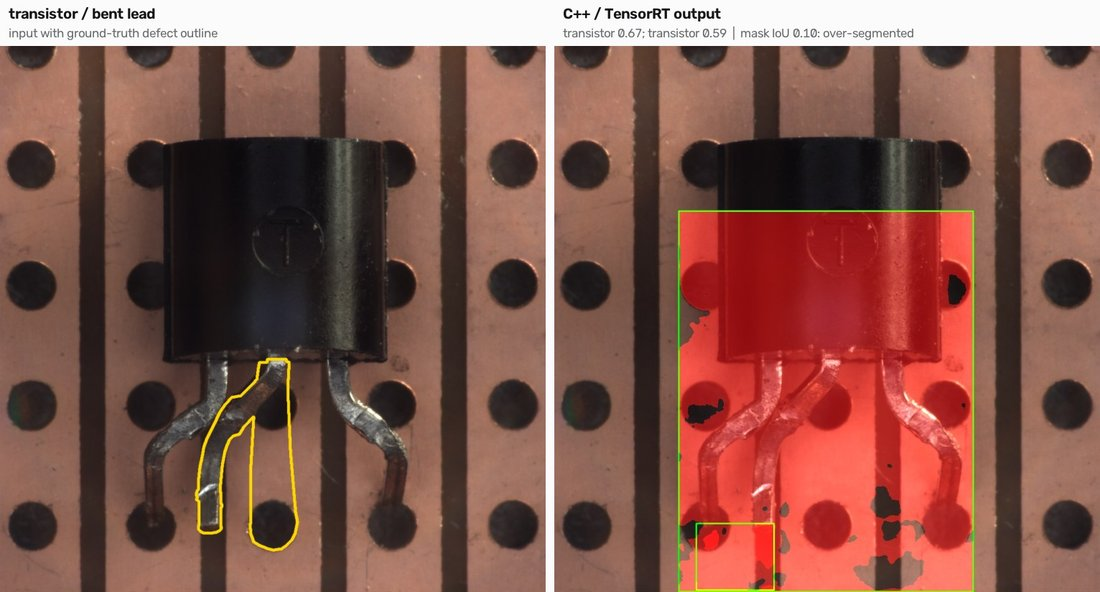

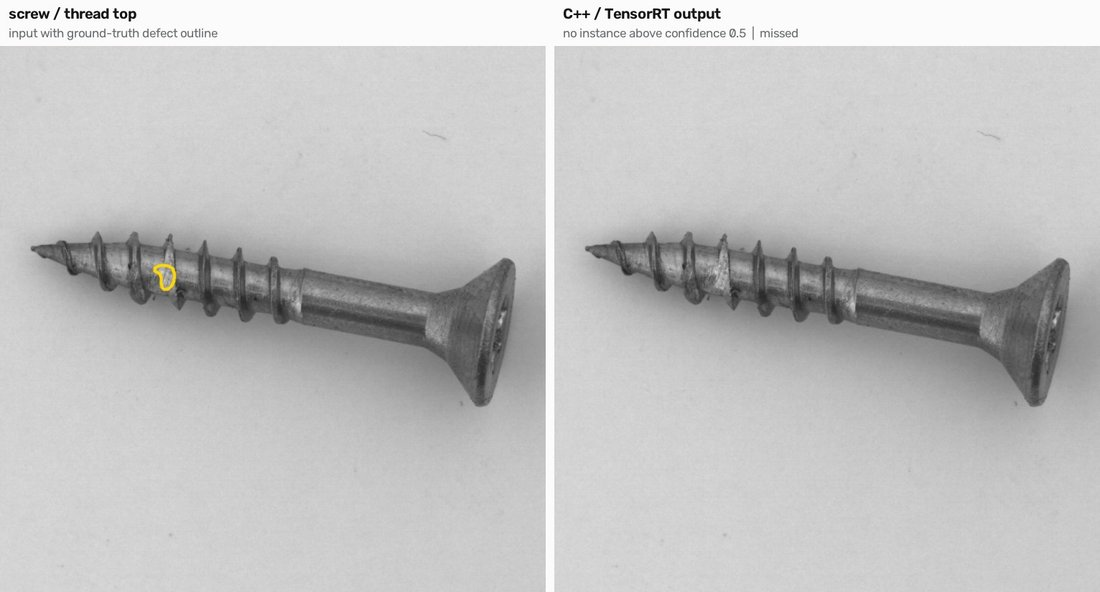

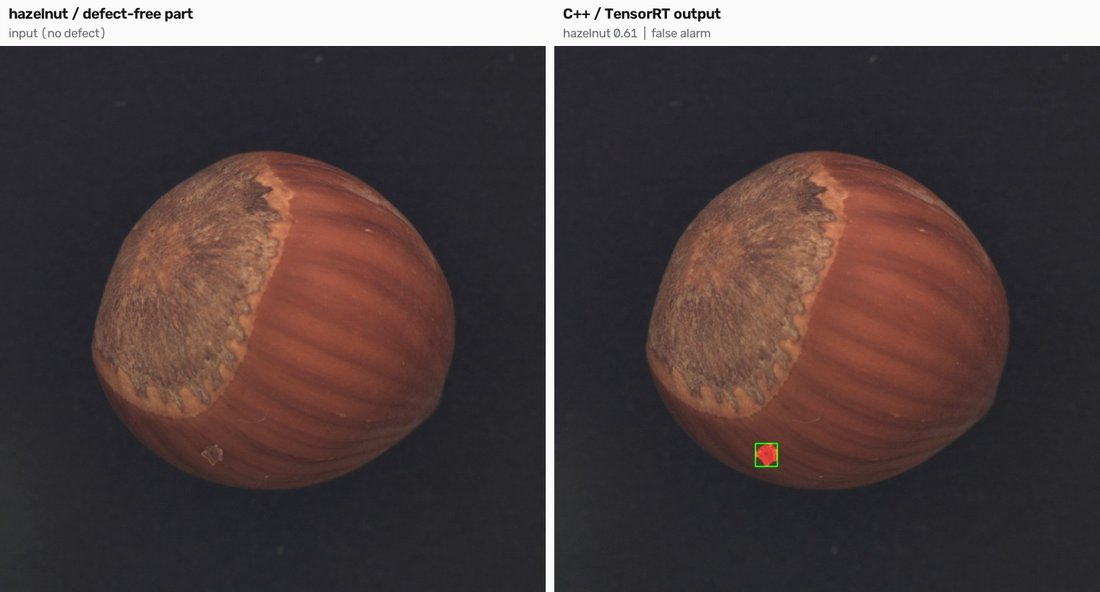

In [9]:
for case in ["cable_bent_wire_006", "wood_liquid_001", "pill_scratch_013",
             "transistor_bent_lead_008", "screw_thread_top_017", "hazelnut_good_013"]:
    show(RESULTS / "cpp_demo" / f"{case}.jpg", width=1100)

**Reading the demo.** 11 of 15 held-out defects are located with mask IoU ≥ 0.5, and the predicted category is right for all 14 detected defects. The failures are informative:

* the damaged screw thread covers ~1,200 pixels, about 0.1% of the image, and nothing clears the app's 0.5 threshold;
* the transistor's bent lead and the squeezed capsule get the right class, but the mask spreads over the whole part. Shape and position defects are harder to delineate than surface marks;
* the leather fold is only half covered;
* on defect-free parts, a small speck on the hazelnut triggers a false alarm, while the screw stays clean.

All 17 case images are in `results/cpp_demo/`.

## 8 · Limitations and next steps

* **No defect-free training images**, so the false-alarm rate is uncontrolled. Next: add `good` images as background, and report image-level AUROC and pixel-level PRO like the MVTec benchmark.
* **Hyperparameter search did not really run** (2/20 iterations). Next: tune on a smaller proxy, then transfer the settings.
* **Bigger was not better.** The 1024 px YOLO11x-seg matched the 640 px YOLO11l-seg on mAP and false-alarmed more on good parts. The next gains are more likely from data (tiling for thin defects, copy-paste augmentation) than from model size.
* **Deployment.** The engine is built from an FP32 graph. Next: an FP16 export, end-to-end timing of the C++ path (pre-processing, NMS and mask decoding included), and command-line arguments instead of fixed file names.